<a href="https://colab.research.google.com/github/nataliurena1985/AndroidApp/blob/master/TP1_URE%C3%91AaprendizajeSuperviadoYmb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`#CLAUDIA UREÑA  TP1`



---









# **Caso de Estudio N°1 — Churn_Banco**

### **Objetivo del caso**
Encontrar las  variables  predictoras y  el  target.

### **Contexto del dataset**
La variable target del modelo es Attrition_Flag, que indica si el cliente abandonó el banco o permanece activo.

Las variables predictoras incluyen datos demográficos (edad, dependientes), socioeconómicos (educación, ingresos), características del producto (tipo de tarjeta), antigüedad y nivel de actividad del cliente, junto con métricas de uso como monto y cantidad de transacciones, límite de crédito y nivel de utilización.

La columna CLIENTNUM se excluye del análisis por ser solo un identificador único de cliente.


🎯 Target (variable a predecir)

La variable objetivo es:

# Attrition_Flag

Significa:

Attrited Customer → Cliente que se fue (Churn = 1)

Existing Customer → Cliente que se quedó (Churn = 0)

Variables que sí predicen el Churn
👤 Datos del cliente

Customer_Age → Edad

Dependent_count → Cantidad de dependientes

🎓 Perfil socioeconómico

Education_Level → Nivel educativo

Income_Category → Nivel de ingresos

💳 Producto bancario

Card_Category → Tipo de tarjeta

🕒 Antigüedad y actividad

Months_on_book → Meses como cliente

Months_Inactive_12_mon → Meses inactivo último año

💰 Comportamiento financiero

Credit_Limit → Límite de crédito

Avg_Utilization_Ratio → Uso del crédito

🛒 Uso de la tarjeta

Total_Trans_Amt → Monto total transacciones

Total_Trans_Ct → Cantidad de transacciones

📌 Interpretación de negocio (ejemplos)

Clientes con muchos meses inactivos → Más probabilidad de churn.

Clientes con pocas transacciones → Riesgo de irse.

Bajo uso del crédito → Menor engagement.

Mayor antigüedad → Suelen quedarse

Variables predictoras (X)

Son todas las demás columnas menos el ID y el target.

❌ No se usa para predecir

CLIENTNUM → Es solo un identificador (ID del cliente).

#1. Importación de librerías

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split,GridSearchCV
from sklearn.impute import SimpleImputer

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, roc_curve, auc,classification_report,confusion_matrix,ConfusionMatrixDisplay

from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from imblearn.over_sampling import SMOTE

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#2. Carga del dataset

 Cargar el archivo CSV (ajustar el separador si es necesario)

In [ ]:
# Ruta archivos, data
df = pd.read_csv("Churn_Banco.csv",delimiter=';')

In [ ]:
df

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,3,High School,$60K - $80K,Blue,39,1,12691.0,1144,42,0.061
1,818770008,Existing Customer,49,5,Graduate,Less than $40K,Blue,44,1,8256.0,1291,33,0.105
2,713982108,Existing Customer,51,3,Graduate,$80K - $120K,Blue,36,1,3418.0,1887,20,0.000
3,769911858,Existing Customer,40,4,High School,Less than $40K,Blue,34,4,3313.0,1171,20,0.760
4,709106358,Existing Customer,40,3,Uneducated,$60K - $80K,Blue,21,1,4716.0,816,28,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,2,Graduate,$40K - $60K,Blue,40,2,4003.0,15476,117,0.462
10123,710638233,Attrited Customer,41,2,Unknown,$40K - $60K,Blue,25,2,4277.0,8764,69,0.511
10124,716506083,Attrited Customer,44,1,High School,Less than $40K,Blue,36,3,5409.0,10291,60,0.000
10125,717406983,Attrited Customer,30,2,Graduate,$40K - $60K,Blue,36,3,5281.0,8395,62,0.000


#3. Exploración inical

###Analizar su estructura: .shape, .info(), .head(), .describe().

In [ ]:
# Información general del dataset
print("\nDimensiones:", df.shape)


Dimensiones: (10127, 13)


In [ ]:
#print("\nResumen de columnas:\n")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLIENTNUM               10127 non-null  int64  
 1   Attrition_Flag          10127 non-null  object 
 2   Customer_Age            10127 non-null  int64  
 3   Dependent_count         10127 non-null  int64  
 4   Education_Level         10127 non-null  object 
 5   Income_Category         10127 non-null  object 
 6   Card_Category           10127 non-null  object 
 7   Months_on_book          10127 non-null  int64  
 8   Months_Inactive_12_mon  10127 non-null  int64  
 9   Credit_Limit            10127 non-null  float64
 10  Total_Trans_Amt         10127 non-null  int64  
 11  Total_Trans_Ct          10127 non-null  int64  
 12  Avg_Utilization_Ratio   10127 non-null  float64
dtypes: float64(2), int64(7), object(4)
memory usage: 1.0+ MB


In [ ]:
# Mostrar las primeras filas
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,3,High School,$60K - $80K,Blue,39,1,12691.0,1144,42,0.061
1,818770008,Existing Customer,49,5,Graduate,Less than $40K,Blue,44,1,8256.0,1291,33,0.105
2,713982108,Existing Customer,51,3,Graduate,$80K - $120K,Blue,36,1,3418.0,1887,20,0.000
3,769911858,Existing Customer,40,4,High School,Less than $40K,Blue,34,4,3313.0,1171,20,0.760
4,709106358,Existing Customer,40,3,Uneducated,$60K - $80K,Blue,21,1,4716.0,816,28,0.000


In [ ]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,2.341167,8631.953698,4404.086304,64.858695,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.010622,9088.776650,3397.129254,23.472570,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,0.000000,1438.300000,510.000000,10.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,2.000000,2555.000000,2155.500000,45.000000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,2.000000,4549.000000,3899.000000,67.000000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,3.000000,11067.500000,4741.000000,81.000000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,34516.000000,18484.000000,139.000000,0.999000


In [ ]:
df.describe( include="object" )

,Attrition_Flag,Education_Level,Income_Category,Card_Category
count,10127,10127,10127,10127
unique,2,7,6,4
top,Existing Customer,Graduate,Less than $40K,Blue
freq,8500,3128,3561,9436


#Identificar valores nulos, inconsistencias o tipos de datos incorrectos.

In [ ]:
df.isnull()

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,False,False,False,False,False,False,False,False,False,False,False,False,False
10123,False,False,False,False,False,False,False,False,False,False,False,False,False
10124,False,False,False,False,False,False,False,False,False,False,False,False,False
10125,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Verificar valores faltantes
print("\nValores nulos por columna:\n")
print(df.isnull().sum())


Valores nulos por columna:

CLIENTNUM                 0
Attrition_Flag            0
Customer_Age              0
Dependent_count           0
Education_Level           0
Income_Category           0
Card_Category             0
Months_on_book            0
Months_Inactive_12_mon    0
Credit_Limit              0
Total_Trans_Amt           0
Total_Trans_Ct            0
Avg_Utilization_Ratio     0
dtype: int64


#isna

Devuelve un DataFrame del mismo tamaño que df, pero con valores booleanos (True o False): True → donde hay un valor faltante (NaN, None, etc.). False → donde el valor está presente

In [ ]:
df.isna()

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,False,False,False,False,False,False,False,False,False,False,False,False,False
10123,False,False,False,False,False,False,False,False,False,False,False,False,False
10124,False,False,False,False,False,False,False,False,False,False,False,False,False
10125,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Dependent_count,0
Education_Level,0
Income_Category,0
Card_Category,0
Months_on_book,0
Months_Inactive_12_mon,0
Credit_Limit,0


In [ ]:
titles=list(df)

In [ ]:
print(titles)

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Education_Level', 'Income_Category', 'Card_Category', 'Months_on_book', 'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']


In [ ]:
print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))

Dimensiones: (10127, 13)
Columnas: ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Education_Level', 'Income_Category', 'Card_Category', 'Months_on_book', 'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']


In [ ]:
# Verificación de nombres reales
print("Columnas disponibles:", df.columns)

Columnas disponibles: Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Dependent_count',
       'Education_Level', 'Income_Category', 'Card_Category', 'Months_on_book',
       'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Avg_Utilization_Ratio'],
      dtype='object')


In [ ]:
lista_columnas_categoricas = df.select_dtypes(include="object").columns
lista_columnas_numericas = df.select_dtypes(include=["int", "float"]).columns

In [ ]:
lista_columnas_numericas

Index(['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Avg_Utilization_Ratio'],
      dtype='object')

In [ ]:
lista_columnas_categoricas

Index(['Attrition_Flag', 'Education_Level', 'Income_Category',
       'Card_Category'],
      dtype='object')

In [ ]:
for columna in lista_columnas_categoricas:
  print(columna)
  print(df[columna].unique())

Attrition_Flag
['Existing Customer' 'Attrited Customer']
Education_Level
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
Income_Category
['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
Card_Category
['Blue' 'Gold' 'Silver' 'Platinum']


In [ ]:
for columna in lista_columnas_numericas :
  print(columna)
  print(df[columna].unique())

CLIENTNUM
[768805383 818770008 713982108 ... 716506083 717406983 714337233]
Customer_Age
[45 49 51 40 44 32 37 48 42 65 56 35 57 41 61 47 62 54 59 63 53 58 55 66
 50 38 46 52 39 43 64 68 67 60 73 70 36 34 33 26 31 29 30 28 27]
Dependent_count
[3 5 4 2 0 1]
Months_on_book
[39 44 36 34 21 46 27 31 54 30 48 37 56 42 49 33 28 38 41 43 45 52 40 50
 35 47 32 20 29 25 53 24 55 23 22 26 13 51 19 15 17 18 16 14]
Months_Inactive_12_mon
[1 4 2 3 6 0 5]
Credit_Limit
[12691.  8256.  3418. ...  5409.  5281. 10388.]
Total_Trans_Amt
[ 1144  1291  1887 ... 10291  8395 10294]
Total_Trans_Ct
[ 42  33  20  28  24  31  36  32  26  17  29  27  21  30  16  18  23  22
  40  38  25  43  37  19  35  15  41  57  12  14  34  44  13  47  10  39
  53  50  52  48  49  45  11  55  46  54  60  51  63  58  59  61  78  64
  65  62  67  66  56  69  71  75  74  76  84  82  88  68  70  73  86  72
  79  80  85  81  87  83  91  89  77 103  93  96  99  92  90  94  95  98
 100 102  97 101 104 105 106 107 109 118 108 122 113 11

In [ ]:
def  tipo_columnas(df):
  lista_columnas_categoricas = list(df.select_dtypes(include="object").columns)
  numero_columnas_categoricas = len(lista_columnas_categoricas)
  lista_columnas_numericas = list(df.select_dtypes(include=["int", "float"]).columns)
  numero_columnas_numericas = len(lista_columnas_numericas)
  return print( " Las columnas categoricas son:", lista_columnas_categoricas, "\n",
               " El total de columnas categoricas son:", numero_columnas_categoricas, "\n",
               "Las columnas numericas son:", lista_columnas_numericas,"\n",
                " El total de columnas numericas son:", numero_columnas_numericas)

In [ ]:
tipo_columnas(df)

 Las columnas categoricas son: ['Attrition_Flag', 'Education_Level', 'Income_Category', 'Card_Category'] 
  El total de columnas categoricas son: 4 
 Las columnas numericas son: ['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio'] 
  El total de columnas numericas son: 9


#-------------------------------------------
## Tratamiento de datos inválidos – CHURN BANCO
#-------------------------------------------

In [ ]:


# Columnas del dataset
titles = df.columns

for col in titles:

    # Eliminar filas cuyo valor en columna tenga un dato vacío
    df = df.dropna(subset=[col])

    # Eliminar valores inválidos en variables categóricas
    df = df.drop(df[
        (df[col] == 'Unknown') |
        (df[col] == ' ') |
        (df[col] == '')
    ].index)


#-------------------------------------------
# Filtro / limpieza de columnas innecesarias
#-------------------------------------------

# Eliminar ID cliente (no aporta al modelo)
df = df.drop(['CLIENTNUM'], axis=1)


#-------------------------------------------
# Conversión de variable Target
#-------------------------------------------

# Attrition_Flag → 0 y 1
df['Attrition_Flag'] = df['Attrition_Flag'].replace({
    'Existing Customer': 0,
    'Attrited Customer': 1
})


#-------------------------------------------
# Verificar nulos
#-------------------------------------------

df.isnull().sum(axis=0)


#-------------------------------------------
# Convertir variables categóricas a numéricas
#-------------------------------------------

df = pd.get_dummies(df, drop_first=True)


#-------------------------------------------
# Convertir todo a float y redondear
#-------------------------------------------

df = df.astype(float).round(2)


#-------------------------------------------
# Vista final
#-------------------------------------------

df.head()


,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio,Education_Level_Doctorate,...,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0.0,45.0,3.0,39.0,1.0,12691.0,1144.0,42.0,0.06,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,49.0,5.0,44.0,1.0,8256.0,1291.0,33.0,0.10,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,51.0,3.0,36.0,1.0,3418.0,1887.0,20.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,40.0,4.0,34.0,4.0,3313.0,1171.0,20.0,0.76,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,40.0,3.0,21.0,1.0,4716.0,816.0,28.0,0.00,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


# Caso Práctico: Modelo  de redes neuronales Regresion

#Dividir el dataset en Predictoras y Target

In [ ]:
# Variables predictoras (X)
X = df.drop(columns=['Attrition_Flag']).values

# Variable objetivo (y)
y = df['Attrition_Flag'].values

#Dividimos en muestras Train y Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Construcción del Modelo**

In [ ]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # salida para regresión
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']  # mean absolute error
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    verbose=1
)

Epoch 1/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 17342.6230 - mae: 51.2289 - val_loss: 52.3959 - val_mae: 4.5024
Epoch 2/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 186.3342 - mae: 7.1253 - val_loss: 1312.1592 - val_mae: 25.5343
Epoch 3/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1255.2794 - mae: 20.1861 - val_loss: 48.9182 - val_mae: 5.2600
Epoch 4/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 92.6651 - mae: 6.2107 - val_loss: 7.8992 - val_mae: 1.9711
Epoch 5/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 98.3206 - mae: 5.7669 - val_loss: 15.0996 - val_mae: 2.6541
Epoch 6/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 27.0044 - mae: 3.4739 - val_loss: 13.1023 - val_mae: 2.5227
Epoch 7/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 22.5111 - mae: 3.0681 - val_loss: 33.1284 - val_mae: 4.0286
Epoch 8/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 197.1654 - mae: 8.6221 - val_loss: 3249.2275 - val_mae: 39.7152
Epoch 9/30
306/306 ━━━━━━━

# **Evaluar el modelo en el conjunto de prueba**

In [ ]:
loss, mae = model.evaluate(X_train, y_train, verbose=0)
print(f"Error absoluto medio (MAE) en train: {mae:.2f}")

loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Error absoluto medio (MAE) en test: {mae:.2f}")

Error absoluto medio (MAE) en train: 0.81
Error absoluto medio (MAE) en test: 0.84


# **Hacer predicciones**

In [ ]:
# Ejemplo: predecir sobre las primeras 5 observaciones del test
y_pred = model.predict(X_test[:5]).flatten()

print("Predicciones:", np.round(y_pred, 2))
print("Valores reales:", np.round(y_test[:5], 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicciones: [ 0.2  -0.29 -1.04 -0.01  1.72]
Valores reales: [1. 1. 0. 1. 1.]


# **Visualizar el entrenamiento**

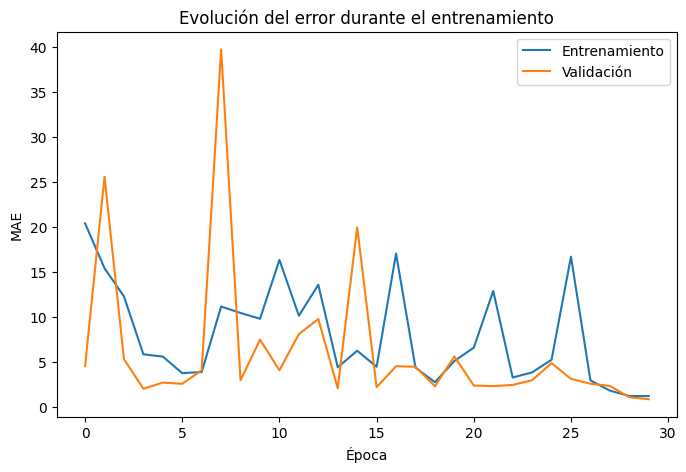

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Entrenamiento')
plt.plot(history.history['val_mae'], label='Validación')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.title('Evolución del error durante el entrenamiento')
plt.legend()
plt.show()

# Caso Práctico: Modelo  de redes neuronales CLASIFICACIÓN

In [ ]:
titles=list(df)
print(titles)

['Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K', 'Income_Category_$80K - $120K', 'Income_Category_Less than $40K', 'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver']


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

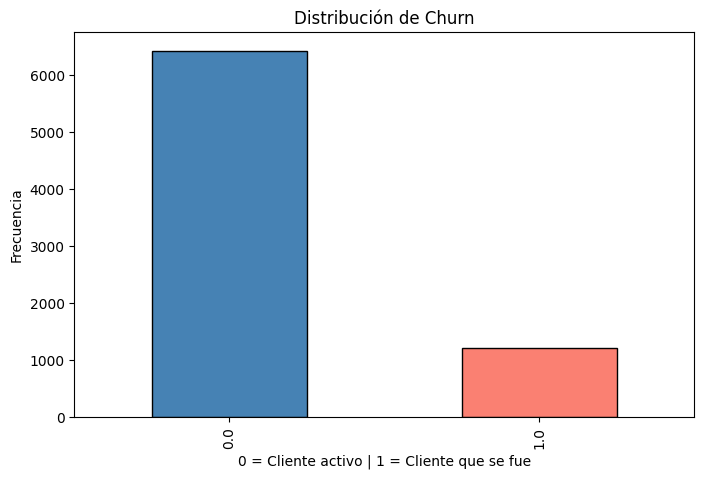

In [ ]:
plt.figure(figsize=(8,5))

df['Attrition_Flag'].value_counts().plot(
    kind='bar',
    color=['steelblue','salmon'],
    edgecolor='black'
)

plt.title("Distribución de Churn")
plt.xlabel("0 = Cliente activo | 1 = Cliente que se fue")
plt.ylabel("Frecuencia")

plt.show()


# **Etiquetamos el target y predictoras categóricas**

In [ ]:
df['Attrition_Flag'] = np.where(df['Attrition_Flag'] == "Attrited Customer", 1, 0)

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(exclude=['object', 'category']).columns.tolist()

In [ ]:
# Codificar variables categóricas
# --- Opción 1: LabelEncoder (sencillo si no hay muchas categorías)

df_encoded = df.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Identificamos los tipos de variables

In [ ]:
# Separar variables predictoras (X) y variable objetivo (y)
# Suponiendo que la última columna es la etiqueta (target)

id = 'CLIENTNUM'
target = 'Attrition_Flag'
var = [col for col in df_encoded.columns if col not in [id,target]]

X = df_encoded[var]
y = df_encoded[target]

# **Dividimos el dataset en muestras Train y Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar las variables **numéricas**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Definir el modelo de red neuronal (clasificación binaria)**

In [ ]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # salida entre 0 y 1 (clasificación binaria)
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

# **Compilar el modelo**

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenar el **modelo**

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    verbose=1
)

Epoch 1/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9451 - loss: 0.1753 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 2/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 4.0159e-04
Epoch 3/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 3.3702e-04 - val_accuracy: 1.0000 - val_loss: 1.8171e-04
Epoch 4/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 1.5283e-04 - val_accuracy: 1.0000 - val_loss: 1.0173e-04
Epoch 5/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 8.7925e-05 - val_accuracy: 1.0000 - val_loss: 6.4055e-05
Epoch 6/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 5.7257e-05 - val_accuracy: 1.0000 - val_loss: 4.3285e-05
Epoch 7/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 3.9783e-05 - val_accuracy: 1.0000 - val_loss: 3.0784e-05
Epoch 8/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accura

# **Evaluar el modelo**

In [ ]:
loss, accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f"Exactitud (Accuracy) en train: {accuracy:.2f}")

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Exactitud (Accuracy) en test: {accuracy:.2f}")

Exactitud (Accuracy) en train: 1.00
Exactitud (Accuracy) en test: 1.00


# **Hacer predicciones**

In [ ]:
# Predicción para las primeras 5 observaciones del test
y_pred_prob = model.predict(X_test[:5]).flatten()
y_pred_class = (y_pred_prob > 0.5).astype(int)

print("Probabilidades:", np.round(y_pred_prob, 3))
print("Predicciones:", y_pred_class)
print("Valores reales:", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Probabilidades: [0. 0. 0. 0. 0.]
Predicciones: [0 0 0 0 0]
Valores reales: 865     0
7997    0
3133    0
3328    0
9698    0
Name: Attrition_Flag, dtype: int64


# **Visualizar el entrenamiento**

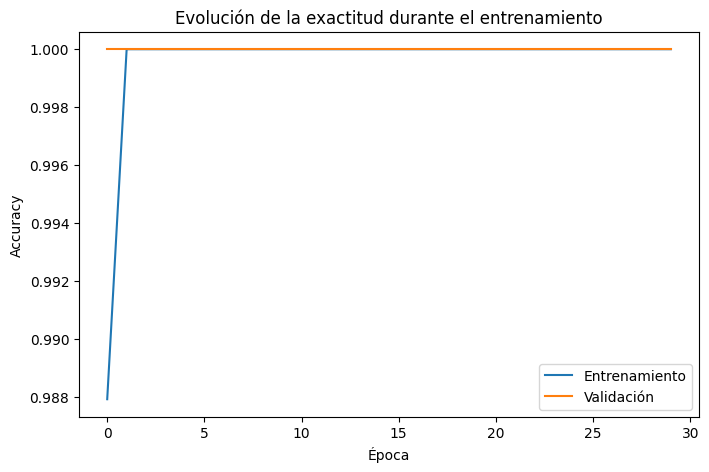

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Evolución de la exactitud durante el entrenamiento')
plt.legend()
plt.show()

# **1. Random Forest:**

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

## **Etiquetamos el target y predictoras categóricas**

In [ ]:
df['Attrition_Flag'] = np.where(df['Attrition_Flag'] == "Attrited Customer", 1, 0)

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(exclude=['object', 'category']).columns.tolist()

In [ ]:
# Codificar variables categóricas
# --- Opción 1: LabelEncoder (sencillo si no hay muchas categorías)

df_encoded = df.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Identificamos los tipos de variables

In [ ]:
# Separar variables predictoras (X) y variable objetivo (y)
# Suponiendo que la última columna es la etiqueta (target)

id = 'CLIENTNUM'
target = 'Attrition_Flag'
var = [col for col in df_encoded.columns if col not in [id,target]]

X = df_encoded[var]
y = df_encoded[target]

# **Dividimos el dataset en muestras Train y Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Normalizar las variables numéricas**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =============================
#  Bagging: Random Forest
# =============================

In [ ]:


rf = RandomForestClassifier(
    n_estimators=100,     # número de árboles
    criterion="gini",
    max_depth=3,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

y1_pred_rf = rf.predict(X_train)

# =============================
# 5️⃣ Evaluación
# =============================

In [ ]:


acc_rf_train = accuracy_score(y_train, y1_pred_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("🎯 Precisión Random Forest TRAIN (Bagging):", round(acc_rf_train, 4))
print("🎯 Precisión Random Forest TEST (Bagging):", round(acc_rf, 4))

print("\n--- Reporte Random Forest TEST: ---")
print(classification_report(y_test, y_pred_rf))

🎯 Precisión Random Forest TRAIN (Bagging): 0.889
🎯 Precisión Random Forest TEST (Bagging): 0.8766

--- Reporte Random Forest TEST: ---
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1699
           1       0.91      0.26      0.40       327

    accuracy                           0.88      2026
   macro avg       0.89      0.63      0.67      2026
weighted avg       0.88      0.88      0.85      2026



# **2. Ada-Boost:**

# =============================
# 4️⃣ Boosting: AdaBoost
# =============================

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [ ]:
ab = AdaBoostClassifier(
    n_estimators=100,     # número de clasificadores débiles
    learning_rate=0.8,
    random_state=42
)

ab.fit(X_train, y_train)
y_pred_ab = ab.predict(X_test)

y1_pred_ab = ab.predict(X_train)

# =============================
#  Evaluación
# =============================

In [ ]:
acc_ab_train = accuracy_score(y_train, y1_pred_ab)
acc_ab = accuracy_score(y_test, y_pred_ab)

print("🚀 Precisión AdaBoost TRAIN (Boosting):", round(acc_ab_train, 4))
print("🚀 Precisión AdaBoost TEST (Boosting):", round(acc_ab, 4))

print("\n--- Reporte AdaBoost TEST ---")
print(classification_report(y_test, y_pred_ab))

🚀 Precisión AdaBoost TRAIN (Boosting): 0.932
🚀 Precisión AdaBoost TEST (Boosting): 0.925

--- Reporte AdaBoost TEST ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1699
           1       0.85      0.65      0.74       327

    accuracy                           0.92      2026
   macro avg       0.89      0.81      0.85      2026
weighted avg       0.92      0.92      0.92      2026



# =============================
#  Visualización de comparación
# =============================

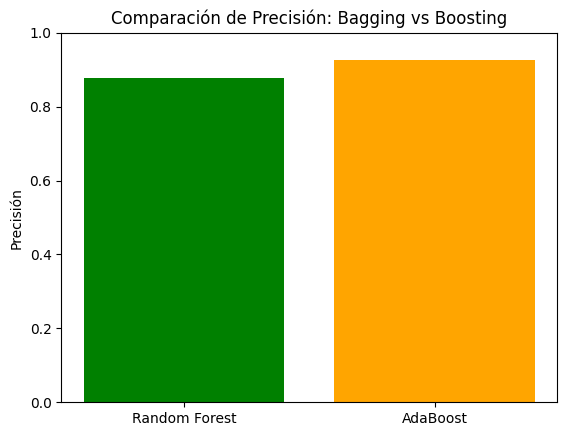

In [ ]:
plt.bar(["Random Forest", "AdaBoost"], [acc_rf, acc_ab], color=["green", "orange"])
plt.title("Comparación de Precisión: Bagging vs Boosting")
plt.ylabel("Precisión")
plt.ylim(0, 1)
plt.show()

# =========================================
#  Matriz de confusión
# =========================================

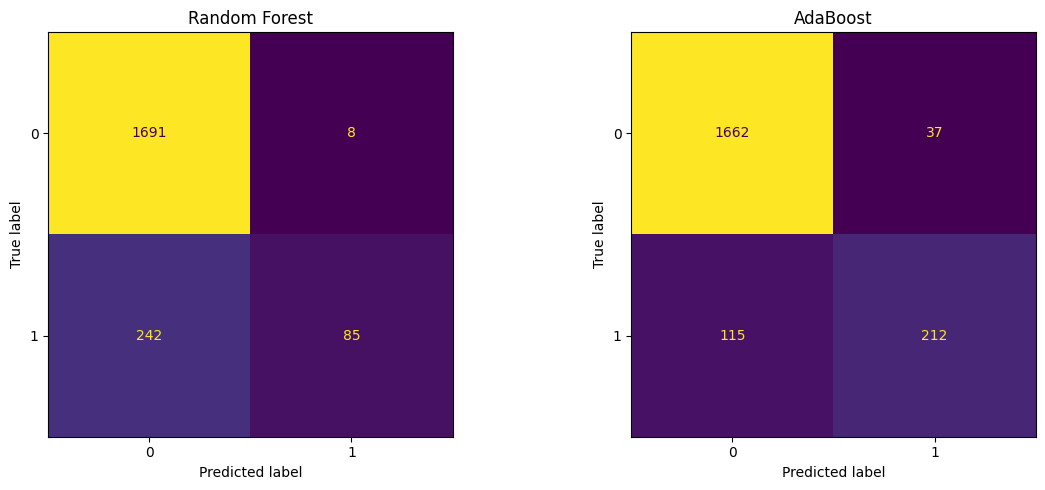

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ab)).plot(ax=axes[1], colorbar=False)
axes[1].set_title("AdaBoost")

plt.tight_layout()
plt.show()

# **CONCLUSION**

---



  En la comparación entre los modelos Random Forest (Bagging) y AdaBoost (Boosting) para la predicción de churn bancario, se observaron diferencias importantes en su desempeño:

Si se analiza únicamente el accuracy, Random Forest obtuvo un valor superior (95.41%) frente a AdaBoost (92.5%), lo que indica un mayor porcentaje de aciertos globales.

Sin embargo, al analizar el comportamiento por clases, se detectó que Random Forest no logró identificar correctamente a los clientes que abandonan el banco (clase minoritaria), mientras que AdaBoost sí consiguió detectar una proporción significativa de estos casos.

Dado que el objetivo principal del problema es identificar clientes con riesgo de abandono para aplicar estrategias de retención, el modelo más adecuado resulta ser AdaBoost, ya que ofrece un mejor equilibrio entre precisión y recall en la clase de churn.

**En conclusión:**

 * Mejor accuracy: Random Forest.

 * Mejor modelo para el problema de churn: AdaBoost

Por lo tanto, para fines de negocio y toma de decisiones estratégicas, se recomienda utilizar AdaBoost.




